# Preprocessing Defenses

This notebook evaluates two classic **input-transformation defenses** against the adversarial example bank built in `robustness_evaluation/10_generate_adversarial_dataset.ipynb`. Both are applied only at **inference time**, with no retraining, no access to the attack, and no gradients:

* **JPEG compression** (Dziugaite et al., 2016): lossy compression discards high-frequency components, which is exactly where most $L_p$-bounded adversarial noise lives.
* **Feature squeezing** (Xu et al., 2017): reducing color bit-depth and applying spatial (median) smoothing shrinks the input space available to an attacker, often reverting a barely-crossed decision boundary back to the correct side.

For every adversarial image already generated, we re-classify the *defended* version and check whether the prediction reverts to the original, correct label, i.e. whether the defense **cures** the attack. This directly produces the "before vs. after defense" comparison referenced in the project roadmap.


In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
import os
from PIL import Image
from scipy.ndimage import median_filter

# Import models (only needed to re-classify the defended images)
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob

### Setup
We only need `preprocess_fn` here (predictions are re-computed on the defended image), plus `target_size` to make sure the reloaded PNG matches what the model expects.

In [2]:
models_dict = {
    'MobileNetV2': {'model': MobileNetV2(weights='imagenet'), 'target_size': (224, 224), 'preprocess_fn': preprocess_mob},
    'EfficientNetB0': {'model': EfficientNetB0(weights='imagenet'), 'target_size': (224, 224), 'preprocess_fn': preprocess_eff},
    'InceptionV3': {'model': InceptionV3(weights='imagenet'), 'target_size': (299, 299), 'preprocess_fn': preprocess_inc},
}

for config in models_dict.values():
    config['model'].trainable = False

MANIFEST_PATH = '../robustness_evaluation/adversarial_dataset_manifest.csv'
ADV_EXAMPLES_DIR = '../robustness_evaluation/adversarial_examples'

manifest_df = pd.read_csv(MANIFEST_PATH)
print(f"Loaded {len(manifest_df)} adversarial examples from {MANIFEST_PATH}")
manifest_df.head()

Loaded 717 adversarial examples from ../robustness_evaluation/adversarial_dataset_manifest.csv


,Image_ID,Model,Attack,Threat_Model,True_Label_Idx,Target_Label_Idx,Adv_Pred_Idx,Success,L2_Distance,Linf_Distance,Queries_Used,Gen_Time_Sec
0,n01532829,MobileNetV2,FGSM,White-box,12,NaN,282,True,19.331955,0.050000,NaN,0.474344
1,n01532829,MobileNetV2,PGD,White-box,12,NaN,676,True,10.763417,0.050000,NaN,8.787341
2,n01532829,MobileNetV2,C&W,White-box,12,NaN,78,True,28.058580,0.367567,NaN,90.185420
3,n01532829,MobileNetV2,DeepFool,White-box,12,NaN,117,True,0.164720,0.005445,NaN,9.709337
4,n01532829,MobileNetV2,TargetedI-FGSM,White-box,12,301.0,301,True,8.643417,0.050000,NaN,6.150602


### Defense Functions
Both defenses operate on the standard `uint8` RGB image (`[0, 255]`, `H x W x 3`), i.e. the same denormalized format already saved to disk by the generation notebook, and hand back an image in the same format, ready to be re-preprocessed for whichever model is being evaluated.

In [3]:
def jpeg_defense(img_uint8, quality=75):
    """Round-trips the image through JPEG compression at the given quality (Dziugaite et al., 2016)."""
    buffer = io.BytesIO()
    Image.fromarray(img_uint8).save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    return np.array(Image.open(buffer).convert('RGB'))

def bit_depth_reduction(img_uint8, bits=4):
    """Feature squeezing (Xu et al., 2017): reduces color depth from 8 bits to `bits` per channel."""
    levels = 2 ** bits
    step = 256 // levels
    return ((img_uint8 // step) * step).astype(np.uint8)

def median_smoothing(img_uint8, size=3):
    """Feature squeezing (Xu et al., 2017): spatial median filter, applied per channel."""
    return np.stack([median_filter(img_uint8[:, :, c], size=size) for c in range(img_uint8.shape[2])], axis=-1).astype(np.uint8)

def feature_squeeze(img_uint8, bits=4, size=3):
    """Combined feature squeezing: bit-depth reduction followed by median smoothing."""
    return median_smoothing(bit_depth_reduction(img_uint8, bits=bits), size=size)

DEFENSES = {
    'JPEG (q=75)': lambda img: jpeg_defense(img, quality=75),
    'Feature Squeeze (4-bit + median-3)': lambda img: feature_squeeze(img, bits=4, size=3),
}

### Evaluation Loop
For every row of the manifest, we reload the saved adversarial PNG, apply each defense, re-preprocess it for the model it was generated on, and re-classify. A defense **cures** the attack when the defended prediction matches the original true label again.

In [4]:
defense_rows = []

for _, row in manifest_df.iterrows():
    model_name = row['Model']
    m_config = models_dict[model_name]
    img_path = os.path.join(ADV_EXAMPLES_DIR, model_name, row['Attack'], f"{row['Image_ID']}.png")
    if not os.path.exists(img_path):
        continue  # image was regenerated with a different NUM_IMAGES / config since the manifest was written

    adv_uint8 = np.array(Image.open(img_path).convert('RGB').resize(m_config['target_size'][::-1]))

    for defense_name, defense_fn in DEFENSES.items():
        defended_uint8 = defense_fn(adv_uint8)

        defended_input = m_config['preprocess_fn'](defended_uint8.astype(np.float32))
        defended_input = tf.expand_dims(defended_input, axis=0)
        defended_probs = m_config['model'].predict(defended_input, verbose=0)
        defended_idx = int(np.argmax(defended_probs, axis=-1)[0])

        cured = bool(defended_idx == row['True_Label_Idx'])

        defense_rows.append({
            'Image_ID': row['Image_ID'],
            'Model': model_name,
            'Attack': row['Attack'],
            'Defense': defense_name,
            'Was_Successful_Attack': bool(row['Success']),
            'Defended_Pred_Idx': defended_idx,
            'Cured': cured,
        })

defense_df = pd.DataFrame(defense_rows)
defense_df.to_csv('defended_metrics.csv', index=False)
print(f"Saved {len(defense_df)} rows -> defended_metrics.csv")

Saved 1434 rows -> defended_metrics.csv


### Before vs. After Defense
We only care about examples that were successful attacks to begin with (an unsuccessful attack has nothing to "cure"). For those, the **post-defense ASR** is `1 - cure rate`: the fraction that is still misclassified after the defense is applied.

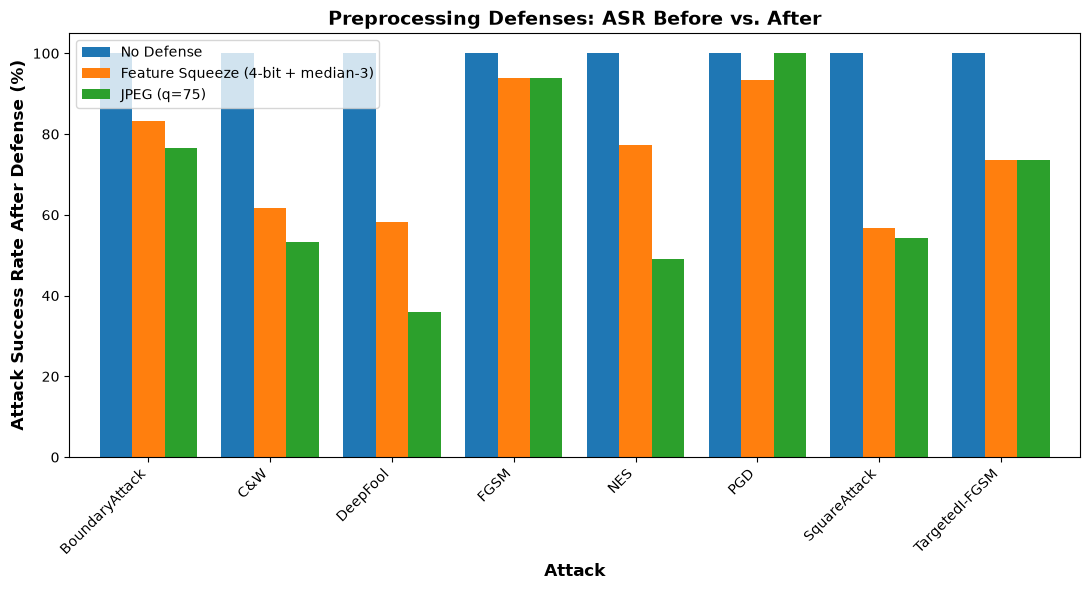

Defense,No Defense,Feature Squeeze (4-bit + median-3),JPEG (q=75)
Attack,,,
BoundaryAttack,100.0,83.3,76.7
C&W,100.0,61.7,53.3
DeepFool,100.0,58.1,36.0
FGSM,100.0,94.0,94.0
NES,100.0,77.2,49.1
PGD,100.0,93.3,100.0
SquareAttack,100.0,56.6,54.2
TargetedI-FGSM,100.0,73.6,73.6


In [5]:
successful = defense_df[defense_df['Was_Successful_Attack']]

post_defense_asr = successful.groupby(['Attack', 'Defense'])['Cured'].apply(lambda s: 100 * (1 - s.mean())).unstack()
baseline_asr = 100.0  # by construction, every row here started as a successful (100% ASR) attack
post_defense_asr.insert(0, 'No Defense', baseline_asr)

ax = post_defense_asr.plot(kind='bar', figsize=(11, 6), width=0.8)
ax.set_ylabel('Attack Success Rate After Defense (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Attack', fontsize=12, fontweight='bold')
ax.set_title('Preprocessing Defenses: ASR Before vs. After', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(title='')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

post_defense_asr.round(1)